In [18]:
import pandas as pd

df = pd.read_csv("co2_mm_mlo.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month  decimal date  average  deseasonalized  ndays  sdev  \
date                                                                          
1958-03-01  1958      3     1958.2027   315.71          314.44     -1 -9.99   
1958-04-01  1958      4     1958.2877   317.45          315.16     -1 -9.99   
1958-05-01  1958      5     1958.3699   317.51          314.69     -1 -9.99   
1958-06-01  1958      6     1958.4548   317.27          315.15     -1 -9.99   
1958-07-01  1958      7     1958.5370   315.87          315.20     -1 -9.99   

             unc  
date              
1958-03-01 -0.99  
1958-04-01 -0.99  
1958-05-01 -0.99  
1958-06-01 -0.99  
1958-07-01 -0.99  


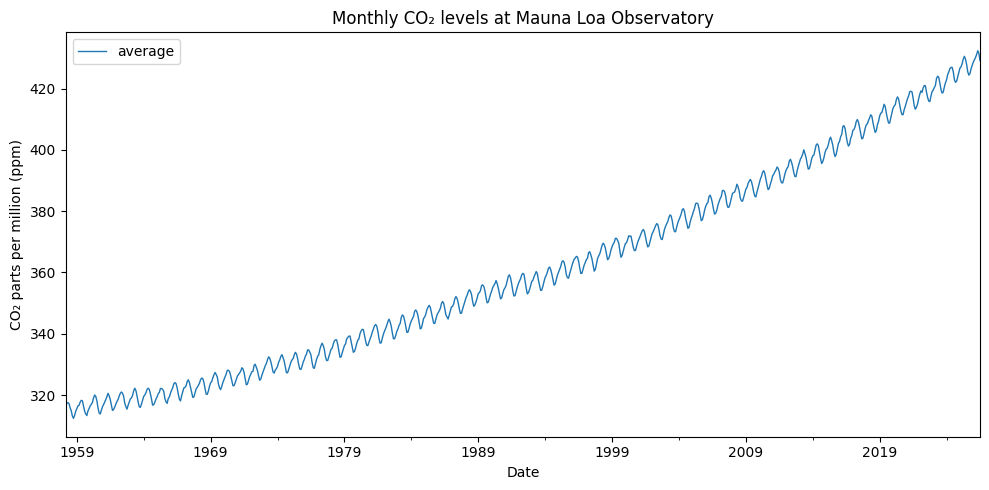

In [19]:
import matplotlib.pyplot as plt

df.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly CO₂ levels at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO₂ parts per million (ppm)")
plt.tight_layout()
plt.show()

In [20]:
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(df["average"])
model_single_fit = model.fit()

In [21]:
forecast_single = model_single_fit.forecast(12)
print(forecast_single)

2026-08-01    429.12
2026-09-01    429.12
2026-10-01    429.12
2026-11-01    429.12
2026-12-01    429.12
2027-01-01    429.12
2027-02-01    429.12
2027-03-01    429.12
2027-04-01    429.12
2027-05-01    429.12
2027-06-01    429.12
2027-07-01    429.12
Freq: MS, dtype: float64


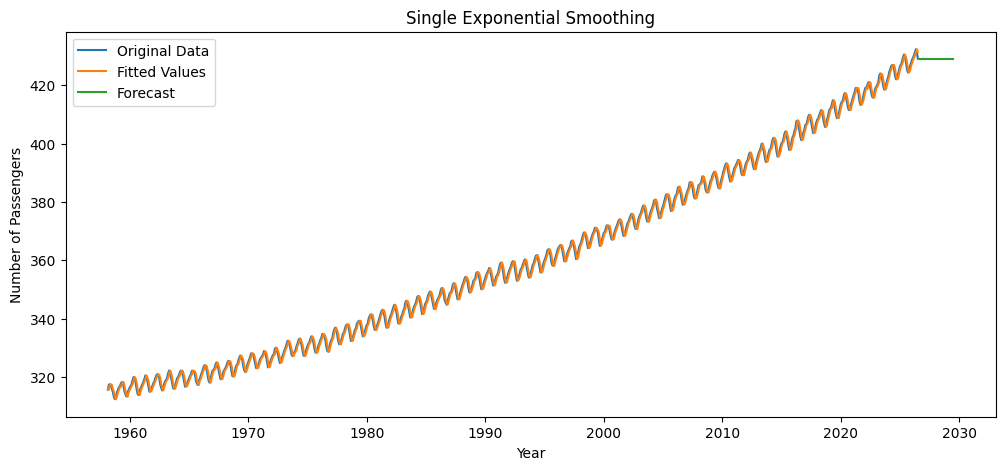

In [22]:
plt.figure(figsize=(12,5))
forecast_single = model_single_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_single_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_single, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Single Exponential Smoothing')
plt.legend()
plt.show()

In [23]:
from statsmodels.tsa.api import Holt

model_double = Holt(df["average"])
model_double_fit = model_double.fit()

In [24]:
forecast_double = model_double_fit.forecast(12)
print(forecast_double)

2026-08-01    426.80
2026-09-01    424.48
2026-10-01    422.16
2026-11-01    419.84
2026-12-01    417.52
2027-01-01    415.20
2027-02-01    412.88
2027-03-01    410.56
2027-04-01    408.24
2027-05-01    405.92
2027-06-01    403.60
2027-07-01    401.28
Freq: MS, dtype: float64


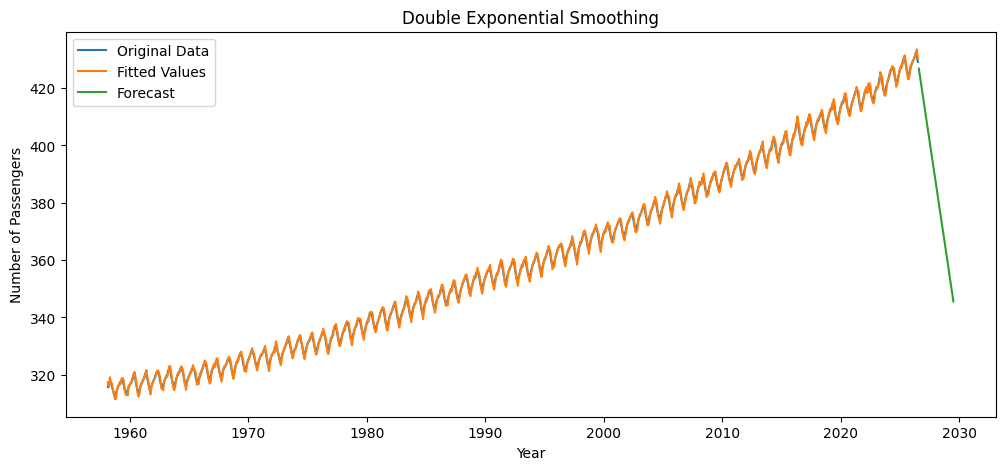

In [25]:
plt.figure(figsize=(12,5))
forecast_double = model_double_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_double_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_double, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Double Exponential Smoothing')
plt.legend()
plt.show()

In [26]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    df["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [27]:
forecast_triple = model_triple_fit.forecast(12)
print(forecast_triple)

2026-08-01    427.245421
2026-09-01    426.040908
2026-10-01    426.321364
2026-11-01    427.875346
2026-12-01    429.272051
2027-01-01    430.474813
2027-02-01    431.353165
2027-03-01    432.066552
2027-04-01    433.512020
2027-05-01    434.255626
2027-06-01    433.612020
2027-07-01    431.759897
Freq: MS, dtype: float64


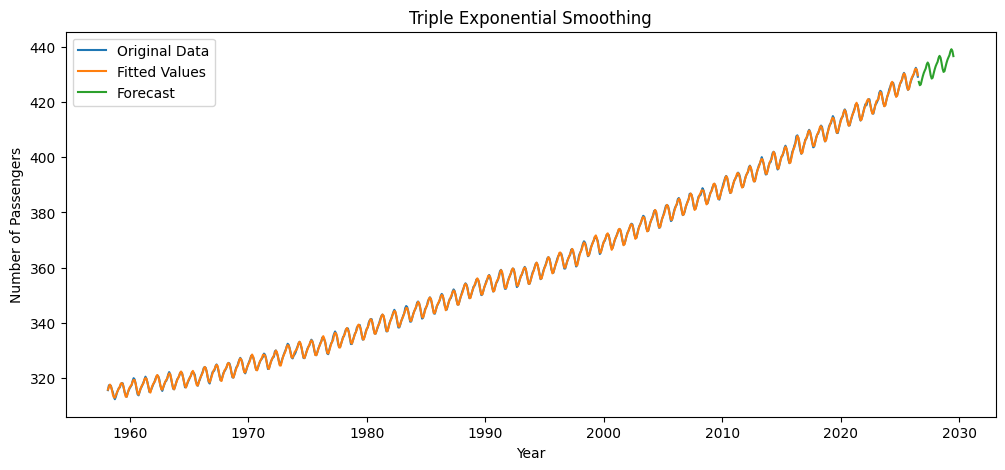

In [28]:
plt.figure(figsize=(12,5))
forecast_triple = model_triple_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

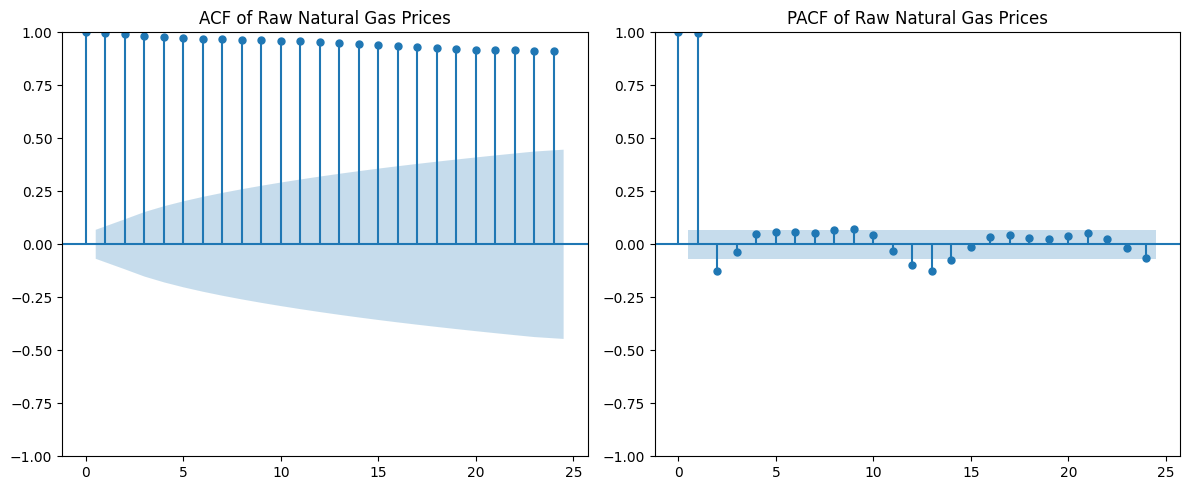

In [29]:
# Step 3: We plot the ACF and PACF of the raw monthly series

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract the raw price series
prices = df["average"]

# Create ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF
plot_acf(prices, lags=24, ax=axes[0])
axes[0].set_title("ACF of Raw Natural Gas Prices")

# PACF
plot_pacf(prices, lags=24, ax=axes[1], method='ywm')
axes[1].set_title("PACF of Raw Natural Gas Prices")

plt.tight_layout()
plt.show()

In [30]:
# Step 4: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(prices)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(prices, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : 5.9076
p-value       : 1.0000
Lags Used     : 21
Observations  : 799

Critical Values:
   1%: -3.4386
   5%: -2.8652
   10%: -2.5687


KPSS Test
----------------
KPSS Statistic : 4.3471
p-value        : 0.0100
Lags Used      : 18

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_4594/3379213664.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(prices, regression='c', nlags='auto')


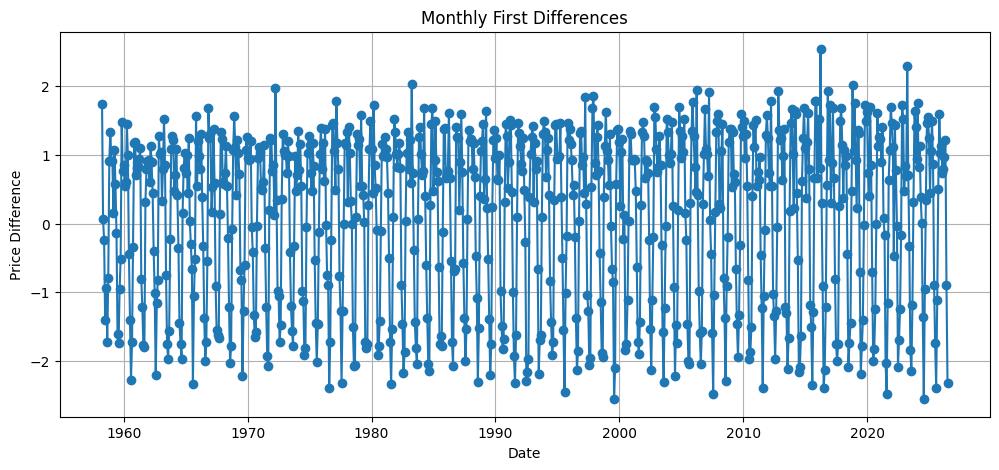

In [33]:
# First difference of the natural gas settlement prices

df['Difference'] = df['average'].diff()

natgas_diff = df.dropna()

plt.figure(figsize=(12,5))
plt.plot(natgas_diff['Difference'], marker='o')
plt.title("Monthly First Differences")
plt.xlabel("Date")
plt.ylabel("Price Difference")
plt.grid(True)
plt.show()

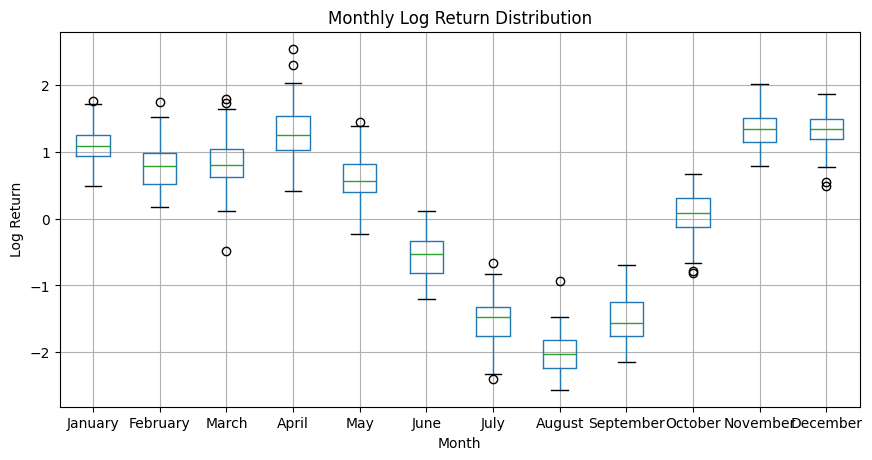

In [34]:
import calendar

# Ordered list of month names
month_order = list(calendar.month_name[1:])   # ['January', 'February', ..., 'December']

natgas_diff = df.dropna().copy()
natgas_diff.loc[:, 'Month'] = natgas_diff.index.month_name()

# Convert Month column to ordered categorical
natgas_diff['Month'] = pd.Categorical(
    natgas_diff['Month'],
    categories=month_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(10,5))
natgas_diff.boxplot(column='Difference', by='Month', ax=ax)
ax.set_title("Monthly Log Return Distribution")
plt.suptitle("")
ax.set_xlabel("Month")
ax.set_ylabel("Log Return")
ax.grid(True)
plt.show()


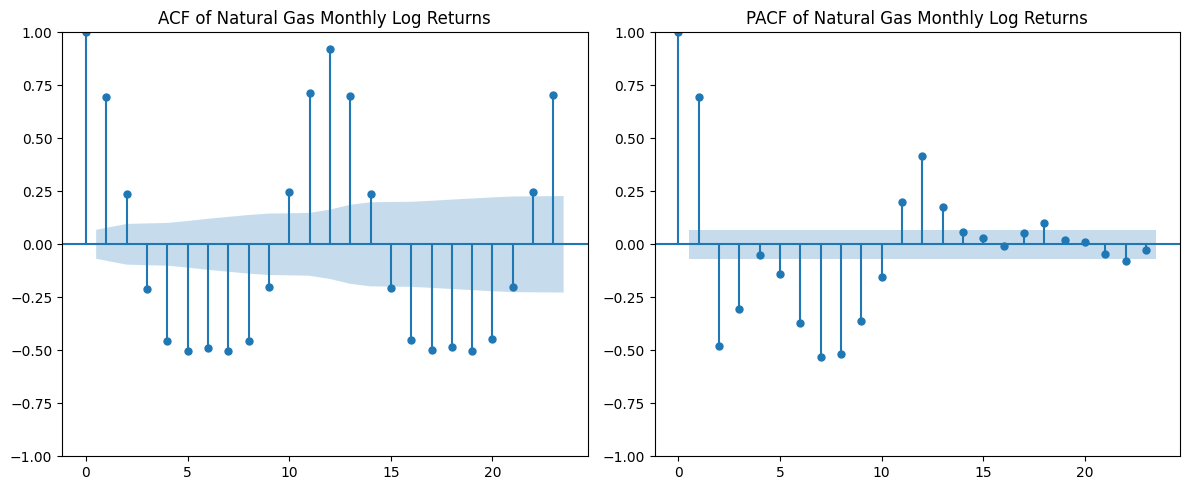

In [35]:
# ACF & PACF of natural gas monthly log returns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract the raw price series
prices2 = natgas_diff['Difference']

# Create ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF
plot_acf(prices2, lags=23, ax=axes[0]) # upto lag 23
axes[0].set_title("ACF of Natural Gas Monthly Log Returns")

# PACF
plot_pacf(prices2, lags=23, ax=axes[1], method='ywm')
axes[1].set_title("PACF of Natural Gas Monthly Log Returns")

plt.tight_layout()
plt.show()

In [36]:
# ADF test & KPSS test of monthly log returns

from statsmodels.tsa.stattools import adfuller, kpss

# Extract the price series
prices2 = natgas_diff['Difference']

# Augmented Dickey-Fuller Test
adf_result = adfuller(prices2)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(prices2, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -5.6658
p-value       : 0.0000
Lags Used     : 21
Observations  : 798

Critical Values:
   1%: -3.4386
   5%: -2.8652
   10%: -2.5687


KPSS Test
----------------
KPSS Statistic : 0.2101
p-value        : 0.1000
Lags Used      : 15

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_4594/1930024524.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(prices2, regression='c', nlags='auto')
